In [28]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

N = 50000

# MC prediction
R9_MC = np.random.beta(8,3,N)

# Data
R9_Data = np.random.beta(12,2.5,N)

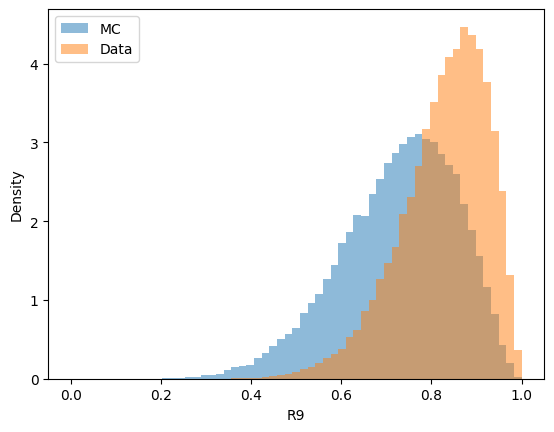

In [29]:
bins=np.linspace(0,1,60)

plt.hist(R9_MC,
         bins=bins,
         density=True,
         alpha=0.5,
         label="MC")

plt.hist(R9_Data,
         bins=bins,
         density=True,
         alpha=0.5,
         label="Data")

plt.xlabel("R9")
plt.ylabel("Density")

plt.legend()

plt.show()

In [30]:
MC_sorted   = np.sort(R9_MC)
Data_sorted = np.sort(R9_Data)

Nmc   = len(MC_sorted)
Ndata = len(Data_sorted)

In [31]:
# CDF values
Fmc = np.zeros(Nmc)

for i in range(Nmc):
    Fmc[i] = (i + 1)/Nmc

Fdata = np.zeros(Ndata)

for i in range(Ndata):
    Fdata[i] = (i + 1)/Ndata

In [32]:
## determine the MC cdf for that point
u = np.zeros(len(R9_MC))

for i, value in enumerate(R9_MC):

    # Find where this value lies in the sorted MC sample
    u[i] = np.interp(
        value,
        MC_sorted,
        Fmc
    )

In [35]:
### invert the data CDF
R9_corrected = np.zeros(len(R9_MC))

for i in range(len(R9_MC)):

    R9_corrected[i] = np.interp(
        u[i],
        Fdata,
        Data_sorted
    )

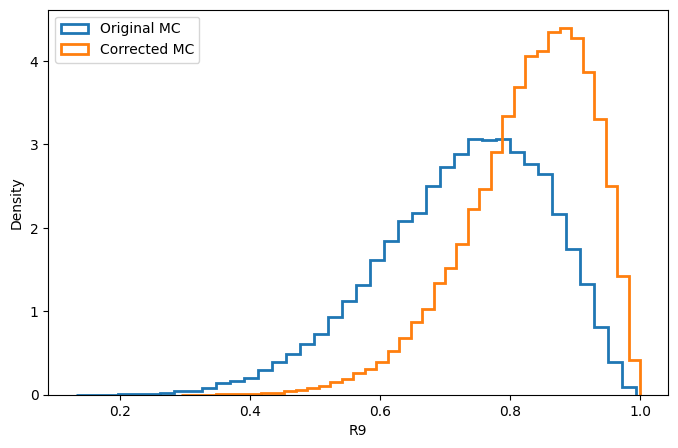

In [37]:
plt.figure(figsize=(8,5))


plt.hist(R9_Data,
         bins=40,
         density=True,
         histtype='step',
         linewidth=2,
         label='Data')
      

plt.hist(R9_MC,
         bins=40,
         density=True,
         histtype='step',
         linewidth=2,
         label='Original MC')

plt.hist(R9_corrected,
         bins=40,
         density=True,
         histtype='step',
         linewidth=2,
         label='Corrected MC')

plt.xlabel("R9")
plt.ylabel("Density")
plt.legend()
plt.show()